# Red neuronal aprobar o no aprobar
Problema de **clasificación binaria**:

- `0` = no aprueba
- `1` = aprueba

Se usan dos variables:

- horas de estudio
- porcentaje de asistencia



## 1. Importar bibliotecas

- `scikit-learn` para entrenar una red neuronal sencilla con `MLPClassifier`.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Creaciòn de un conjunto de datos

Cada fila representa un estudiante.

Variables de entrada:

- `study_hours`: horas de estudio por semana.
- `attendance`: porcentaje de asistencia.

Variable objetivo:

- `passed`: 1 si aprueba, 0 si no aprueba.


In [15]:
data = pd.DataFrame({
    "study_hours": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 8, 8, 9, 10, 10, 11, 12, 12],
    "attendance":   [40, 45, 55, 50, 60, 55, 65, 60, 70, 65, 75, 70, 80, 85, 82, 88, 92, 90, 95, 98],
    "passed":       [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
})

data

,study_hours,attendance,passed
0,1,40,0
1,2,45,0
2,2,55,0
3,3,50,0
4,3,60,0
5,4,55,0
6,4,65,1
7,5,60,0
8,5,70,1
9,6,65,1


## 3. Visualizaciòn de los datos


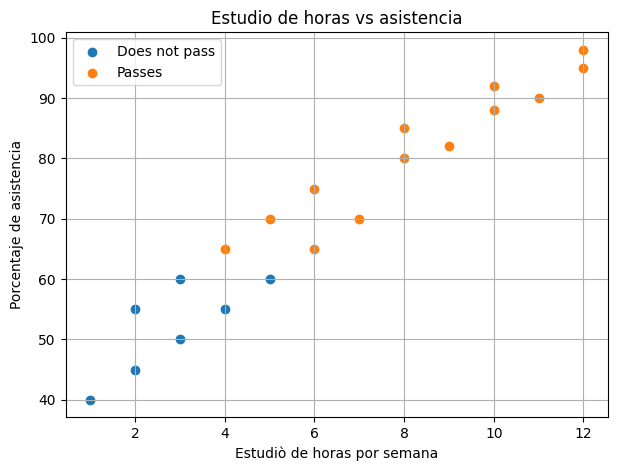

In [27]:
plt.figure(figsize=(7, 5))

not_passed = data[data["passed"] == 0]
passed = data[data["passed"] == 1]

plt.scatter(not_passed["study_hours"], not_passed["attendance"], label="Does not pass")
plt.scatter(passed["study_hours"], passed["attendance"], label="Passes")

plt.xlabel("Estudiò de horas por semana")
plt.ylabel("Porcentaje de asistencia")
plt.title("Estudio de horas vs asistencia")
plt.legend()
plt.grid(True)
plt.show()

## 4. Conjunto de entrenamiento y prueba


In [ ]:
X = data[["study_hours", "attendance"]]
y = data["passed"]

print("Variables de entrada:")
display(X.head())

print("Variable objetivo:")
display(y.head())

Input variables:


,study_hours,attendance
0,1,40
1,2,45
2,2,55
3,3,50
4,3,60


Target variable:


0    0
1    0
2    0
3    0
4    0
Name: passed, dtype: int64

## 5. Dividir en entrenamiento y prueba

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Cantidad de registros para entrenamiento:", X_train.shape[0])
print("Cantidad de datos para pruebas:", X_test.shape[0])

Cantidad de registros para entrenamiento: 14
Cantidad de datos para pruebas: 6


## 6. Normalizar los datos



In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:")
print(X_train_scaled[:5])

Scaled training data:
[[ 0.89486287  0.80114576]
 [-0.56189064 -0.85367991]
 [ 1.18621357  1.16888479]
 [-0.27053994  0.06566769]
 [ 0.02081076  0.37211688]]


## 7. Crear la red neuronal

Red neuronal multicapa sencilla.

Arquitectura:

```text
2 entradas → 4 neuronas ocultas → 1 salida binaria
```

En `MLPClassifier`:

- `hidden_layer_sizes=(4,)` significa una capa oculta con 4 neuronas.
- `activation="relu"` usa ReLU en la capa oculta.
- `solver="adam"` usa un optimizador para ajustar los pesos.
- `max_iter=1000` indica el máximo de iteraciones de entrenamiento.


## ¿Qué es Adam y cómo funciona?

*Adaptive Moment Estimation**.  
Es un algoritmo de optimización que se usa para entrenar redes neuronales.

Su objetivo es ajustar los **pesos** y **sesgos** del modelo para reducir el error de predicción.

Procedimiento para entrenar una red neuronal:

1. La red recibe los datos de entrada.
2. Realiza una predicción.
3. Compara la predicción con el valor real.
4. Calcula el error.
5. Adam modifica los pesos y sesgos para que el error sea menor en la siguiente iteración.

Adam combina dos ideas importantes:

### 1. Momentum

Adam recuerda la dirección en la que el error venía disminuyendo.

Esto ayuda a que el modelo no cambie de dirección de forma brusca y avance con mayor estabilidad hacia una mejor solución.

### 2. Tasa de aprendizaje adaptativa

Adam ajusta automáticamente cuánto debe cambiar cada peso.

Algunos pesos necesitan cambios grandes y otros cambios pequeños.  
Por eso Adam no usa exactamente el mismo ajuste para todos los pesos.


Adam ayuda a decidir:

- hacia dónde moverse
- qué tan grande debe ser cada paso
- cómo evitar movimientos inestables

Por eso Adam suele aprender más rápido y de forma más estable que otros métodos básicos.

Finalmente, Adam será el encargado de modificar los pesos internos de la red neuronal durante el entrenamiento.



In [20]:

model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

model

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(4,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 8. Entrenar el modelo

Durante el entrenamiento, la red ajusta sus pesos para reducir el error entre sus predicciones y los valores reales.


In [ ]:
model.fit(X_train_scaled, y_train)

print("Training completed.")

Training completed.


## 9. Hacer predicciones


In [22]:
# Make predictions
y_pred = model.predict(X_test_scaled)

results = X_test.copy()
results["real_class"] = y_test.values
results["predicted_class"] = y_pred

results

,study_hours,attendance,real_class,predicted_class
3,3,50,0,0
13,8,85,1,1
7,5,60,0,1
11,7,70,1,1
19,12,98,1,1
16,10,92,1,1


## 10. Evaluar el modelo

Para clasificación usamos métricas como:

- accuracy
- matriz de confusión
- precision
- recall
- f1-score


In [28]:
accuracy = accuracy_score(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("\nConfusion matrix:")
print(matrix)

print("\nReporte")
print(classification_report(y_test, y_pred, target_names=["No aprueba", "Aprueba"]))

Accuracy: 0.8333

Confusion matrix:
[[1 1]
 [0 4]]

Reporte
              precision    recall  f1-score   support

  No aprueba       1.00      0.50      0.67         2
     Aprueba       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



## 11. Interpretar probabilidades

Además de predecir la clase final, podemos pedirle a la red la probabilidad de cada clase.


In [33]:
# Predecir probabilidades
probabilidades = model.predict_proba(X_test_scaled)

resultados_probabilidades = X_test.copy()
resultados_probabilidades["clase_real"] = y_test.values
resultados_probabilidades["probabilidad_no_aprueba"] = probabilidades[:, 0]
resultados_probabilidades["probabilidad_aprueba"] = probabilidades[:, 1]
resultados_probabilidades["clase_predicha"] = y_pred

resultados_probabilidades.round(4)

,study_hours,attendance,clase_real,probabilidad_no_aprueba,probabilidad_aprueba,clase_predicha
3,3,50,0,0.9999,0.0001,0
13,8,85,1,0.0397,0.9603,1
7,5,60,0,0.4977,0.5023,1
11,7,70,1,0.0397,0.9603,1
19,12,98,1,0.0397,0.9603,1
16,10,92,1,0.0397,0.9603,1


## 12. Probar con un estudiante nuevo

Un estudiante estudia 7 horas por semana y tiene 78% de asistencia.

Queremos saber si la red predice que aprueba.


In [40]:
nuevo_estudiante = pd.DataFrame({
    "study_hours": [7],
    "attendance": [78]
})


nuevo_estudiante_escalado = scaler.transform(nuevo_estudiante)

prediccion = model.predict(nuevo_estudiante_escalado)
probabilidad_prediccion = model.predict_proba(nuevo_estudiante_escalado)

print("Nuevo estudiante:")
display(nuevo_estudiante)

print("Clase predicha:", prediccion[0])
print("Probabilidad de no aprobar:", round(probabilidad_prediccion[0][0], 4))
print("Probabilidad de aprobar:", round(probabilidad_prediccion[0][1], 4))

Nuevo estudiante:


,study_hours,attendance
0,7,78


Clase predicha: 1
Probabilidad de no aprobar: 0.0397
Probabilidad de aprobar: 0.9603


## 13. Ver la función de pérdida durante el entrenamiento

La pérdida indica qué tanto se equivoca el modelo durante el entrenamiento.

En general, si la pérdida baja, significa que el modelo está aprendiendo.


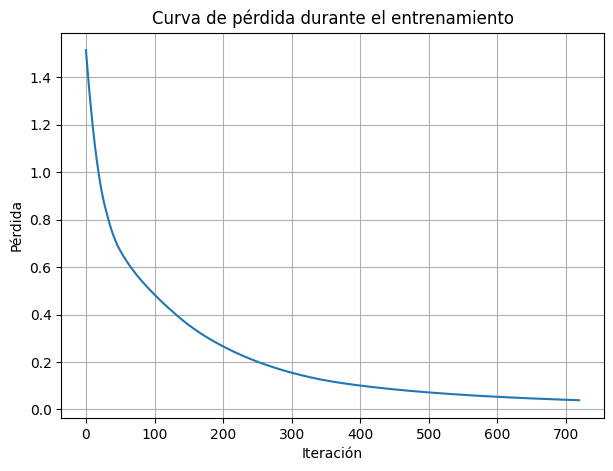

In [41]:
plt.figure(figsize=(7, 5))
plt.plot(model.loss_curve_)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Curva de pérdida durante el entrenamiento")
plt.grid(True)
plt.show()

La curva de pérdida muestra que la red neuronal aprendió correctamente durante el entrenamiento. Al inicio, el error era alto porque el modelo todavía no había ajustado bien sus pesos, pero conforme avanzaron las iteraciones la pérdida disminuyó de forma constante y estable. 

Esto indica que el modelo fue reduciendo sus errores poco a poco hasta alcanzar un valor bajo, lo cual sugiere una buena convergencia. Sin embargo, esta gráfica solo evalúa el aprendizaje en entrenamiento, por lo que también es necesario revisar los resultados en los datos de prueba.

## Ejercicios

1. Cambia el número de neuronas ocultas de `(4,)` a `(8,)`.
2. Cambia la función de activación de `"relu"` a `"tanh"`.
3. Modifica el estudiante nuevo y observar cómo cambia la probabilidad.
4. Agregar más filas al conjunto de datos.
5. Analiza e interpeta cada uno de los resultados anteriores
